# EDA & ML Regresión Logística

Cómo funciona la  R. Logística
| Aspecto           | Regresión Lineal                   |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Regresión                          |
| Salida del modelo | Valor numérico continuo            |
| Objetivo          | Predecir una variable cuantitativa |
| Ejemplo           | Predecir el coste del seguro       |


# Paso 0: **Imports**


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Split
from sklearn.model_selection import train_test_split

# Escalado
from sklearn.preprocessing import StandardScaler

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas de regresión
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


import pickle


# **EDA**

## Paso 1: **Data & Problem Description**

In [63]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv", sep=',')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


###  **Problem desciption**

* **Objetivo:** Predecir el coste del seguro médico de una persona en función de variables como; edad, BMI, número de hijos, si fuma, región, sexo...


* **Planteamiento:** Esto es un problema de regresión supervisada, porque el objetivo es predecir un valor numérico continuo. La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, **cuál va a ser la prima (coste) que debe asumir cada uno de ellos**. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

###  **Data Variables**

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 1338 filas y 7 columnas  
> * Los datos que aporta el datset son 4 columnas de tipo numérico (enteros y decimales) y 3 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(2), int64(2), object(3)``  
>  
> | variable | tipo              |  
> | -------- | ----------------- |  
> | age      | numérica          |  
> | sex      | categórica        |  
> | bmi      | numérica          |  
> | children | numérica          |  
> | smoker   | categórica        |  
> | region   | categórica        |  
> | charges  | numérica (target) |  
>  
> 1. ``age``. Edad del beneficiario principal (numérico)
> 2. ``sex``. Género del beneficiario principal (categórico)
> 3. ``bmi``. índice de masa corporal (numérico)
> 4. ``children``. Número de niños/dependientes cubiertos por un seguro médico (numérico)
> 5. ``smoker``. ¿Es fumador? (categórico)
> 6. ``region``. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
> 7. ``charges``. Prima del seguro médico (numérico)


## Paso 2: **Limpieza de datos**

### **Duplicados y valores nulos**

In [65]:
df.duplicated().sum()

np.int64(1)

In [66]:
df.isna().sum() # Compruebo si hay datos nulos (datos faltantes)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [67]:
df_dupl = df[df.duplicated(subset=df.columns, keep=False)]
df_dupl # Print df de las columnas duplicadas para ver la fila duplicada

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [68]:
df = df.drop_duplicates()

> **Conclusión de la limpieza de datos:** Las columnas no contienen valores nulos y hay solamente una fila duplicada.

## Paso 3: **Análisis de las variables:**

### **Variable target** 
> * ``charges``, variable target escogida ya que nos indica el valor prima del seguro médico que ya tenía cada persona.

In [69]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [70]:
df['charges'].max()

np.float64(63770.42801)

In [71]:
df[df['charges']>30000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1308,25,female,30.200,0,yes,southwest,33900.65300
1313,19,female,34.700,2,yes,southwest,36397.57600


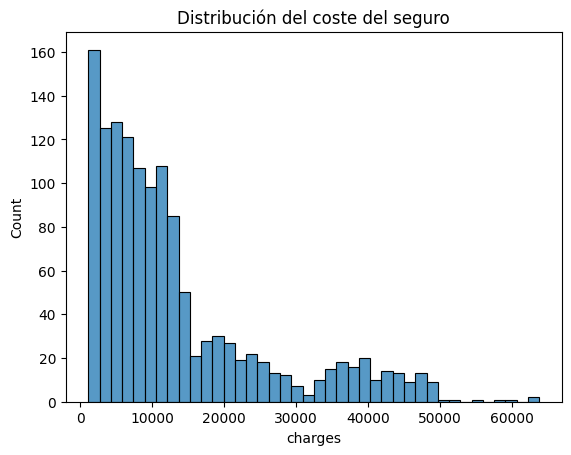

In [72]:
sns.histplot(df["charges"], bins=40)

plt.title("Distribución del coste del seguro")

plt.show()

### **Columna vs Target**

* **Edad**

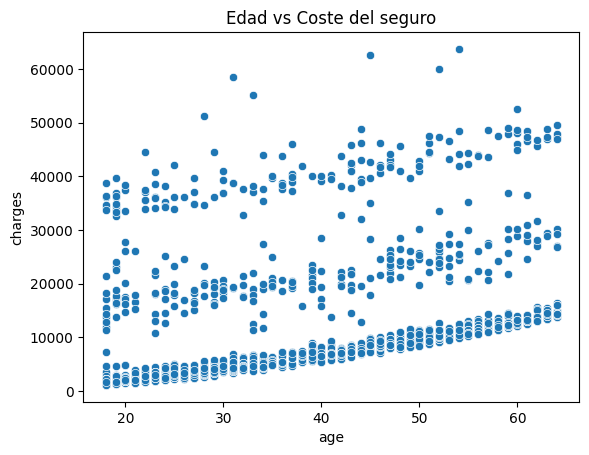

In [73]:
sns.scatterplot(data=df, x="age", y="charges")

plt.title("Edad vs Coste del seguro")

plt.show()

* **Fumador**

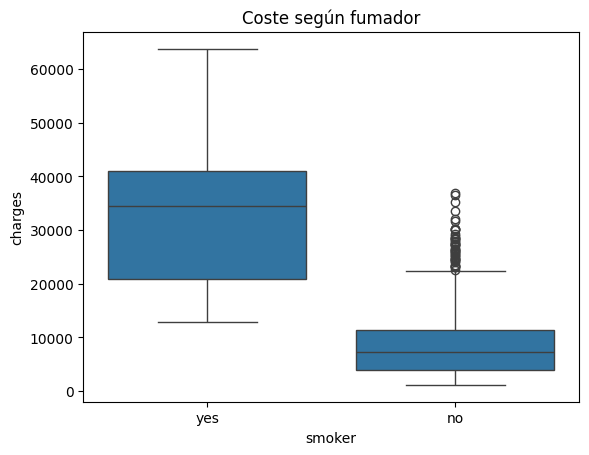

In [74]:
sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Coste según fumador")

plt.show()

> **Observaciones:**  
> * La distribución de charges es asimétrica hacia la derecha, lo que indica la presencia de valores altos extremos. Al analizar la relación entre charges y la variable smoker, se observa que los fumadores tienden a presentar costes de seguro significativamente más elevados, lo que explica la presencia de estos valores extremos.  
> * Existe una tendencia positiva entre edad y coste del seguro. A medida que aumenta la edad, el coste del seguro tiende a incrementarse, aunque con una alta variabilidad.

### **Normalizado de datos categóricos**

In [75]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### **Correlaciones**

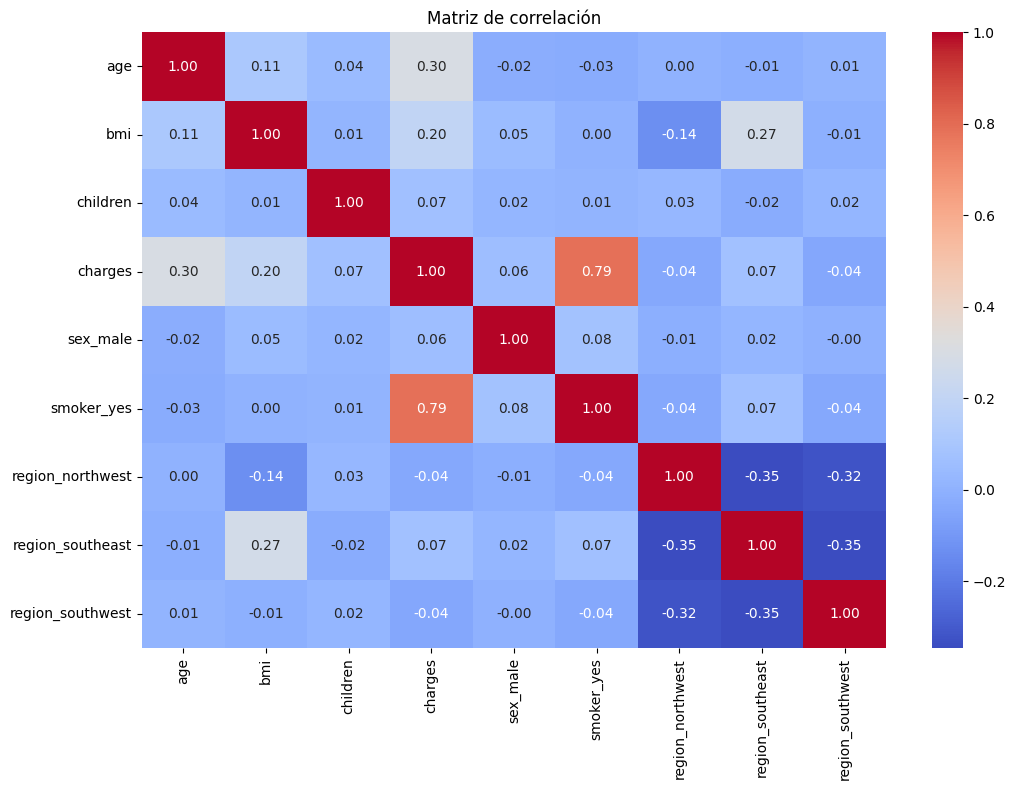

In [76]:
corr = df_encoded.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

> **Conclusiones de la matriz de correlación:**  
> * smoker_yes presenta la correlación positiva más alta con charges, lo que indica que fumar tiene un fuerte impacto en el coste del seguro.  
> * age también muestra una correlación positiva moderada, indicando que los costes tienden a aumentar con la edad.  
> * bmi presenta una correlación positiva más débil.  
> * Las variables region y sex muestran correlaciones muy bajas, por lo que su impacto en el coste del seguro es menor.

# **ML**

## Paso 1: **Split Data: train & test**

In [77]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

## Paso 2: **Escalado de datos**

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Paso 3: **Modelo inical: Linear Regression**

In [80]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Predicción del modelo**

In [81]:
y_pred = model.predict(X_test_scaled)
y_pred[:5]

array([ 8143.69388412,  5737.11568259, 14369.31487618, 31745.51363586,
        8962.38665706])

## Paso 4: **Métricas**

### 1. **MAE (Mean Absolute Error)**

> Indica el error medio en dólares.

In [82]:
mae = mean_absolute_error(y_test, y_pred)
mae

4177.045561036324

### 2. **MSE**

> Penaliza más errores grandes.

In [83]:
mse = mean_squared_error(y_test, y_pred)
mse

35478020.67523561

### 3. **R² Score**

> Indica qué porcentaje de la variabilidad explica el modelo.

In [84]:
r2 = r2_score(y_test, y_pred)
r2

0.8069287081198011

> **Observación:** El modelo explica aproximadamente 81% de la variabilidad del coste del seguro médico

## Paso 5: **Comparación con otros modelos de regresión**

### **Desicion Tree Regressor**

In [85]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_scaled, y_train)
pred_tree = tree.predict(X_test_scaled)
print("R2 Tree:", r2_score(y_test, pred_tree))

R2 Tree: 0.8097857115858496


### **Random Forest Regressor**

In [86]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("R2 Random Forest:", r2_score(y_test, pred_rf))

R2 Random Forest: 0.8782485052664795


### **Comparación de modelos**

In [87]:
results = {"Linear Regression": r2_score(y_test, y_pred),"Decision Tree": r2_score(y_test, pred_tree),"Random Forest": r2_score(y_test, pred_rf)}
results

{'Linear Regression': 0.8069287081198011,
 'Decision Tree': 0.8097857115858496,
 'Random Forest': 0.8782485052664795}

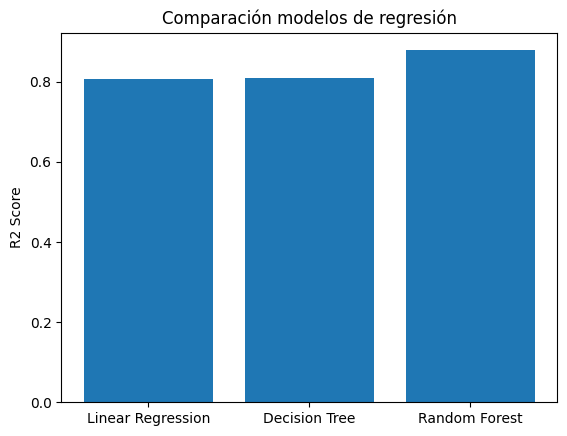

In [88]:
plt.bar(results.keys(), results.values())
plt.title("Comparación modelos de regresión")
plt.ylabel("R2 Score")
plt.show()

> **Se compararon distintos modelos:** Linear Regression, Decision Tree, Random Forest.  
> * El modelo Random Forest obtiene el mejor rendimiento con un R² ≈ 0.88, superando tanto a la regresión lineal como al árbol de decisión. Esto sugiere que la relación entre las variables y el coste del seguro no es completamente lineal, y que los modelos basados en árboles pueden capturar mejor estas interacciones complejas.

* **Hiperparametrización de Random Forest**

In [89]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({    "feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)
importance_df

,feature,importance
4,smoker_yes,0.600777
1,bmi,0.216088
0,age,0.135726
2,children,0.022938
3,sex_male,0.007076
5,region_northwest,0.006779
6,region_southeast,0.006045
7,region_southwest,0.004570


> **Observaciones:** Las variables que más influyen en el coste del seguro suelen ser: smoker, age, bmi. Fumar es el factor más determinante en el coste del seguro médico.

## Paso 6: **Guardado de data codificada**

In [90]:
with open("random_forest_insurance_model.pkl", "wb") as file:pickle.dump(rf, file)

## **Conclusión final**

> El modelo Random Forest obtuvo el mejor rendimiento con la métrica R². Esto sugiere que el problema presenta relaciones no lineales entre variables, que los modelos basados en árboles pueden capturar mejor que la regresión lineal. En conclusión, el modelo Random Forest resulta ser el más adecuado para este dataset, proporcionando predicciones más precisas del coste del seguro médico